 # road network

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
G = nx.Graph() # adirected graph

In [3]:
# edge coordinates

df = pd.read_csv(r'C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\raw\edge_coords.csv',
                 index_col=False)
df = df[df['track']==False] # filter all road netweor
df.columns

Index(['id', 'node0', 'x_0', 'y_0', 'z_0', 'node1', 'x_1', 'y_1', 'z_1', 'bus',
       'tram', 'track', 'streetType'],
      dtype='object')

In [4]:
# get a list of node edges
node_df = df[['node0', 'node1']]
node_df['tuple'] = node_df.apply(lambda x: tuple(x), axis=1)
node_edge = node_df['tuple'].to_list()

C:\Users\prade\AppData\Local\Temp\ipykernel_14740\280512643.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  node_df['tuple'] = node_df.apply(lambda x: tuple(x), axis=1)


In [5]:
# creating nodes
unique_node_0 = df[['node0', 'x_0', 'y_0', 'z_0']]
unique_node_1 = df[['node1', 'x_1', 'y_1', 'z_1']].rename(columns={
    'node1': 'node0', 'x_1': 'x_0', 'y_1': 'y_0', 'z_1':'z_0'
})
unique_node = pd.concat([unique_node_0, unique_node_1], axis=0)
unique_node.drop_duplicates(inplace=True)

del unique_node_0, unique_node_1

unique_node['node_attribute'] = unique_node.apply(lambda x: [int(x[0].item()), {'x': x[1].item(), 
                                                                    'y': x[2].item(),
                                                                    'z': x[3].item()}],
                                                                    axis=1)

for row in unique_node['node_attribute'].to_list():
    node = row[0]
    key_atr = row[1]
    if node == 107920:
        None
    G.add_node(node, **key_atr)

C:\Users\prade\AppData\Local\Temp\ipykernel_14740\2702652774.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  unique_node['node_attribute'] = unique_node.apply(lambda x: [int(x[0].item()), {'x': x[1].item(),
C:\Users\prade\AppData\Local\Temp\ipykernel_14740\2702652774.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'y': x[2].item(),
C:\Users\prade\AppData\Local\Temp\ipykernel_14740\2702652774.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

In [6]:
G.number_of_nodes(), len(unique_node)

(2414, 2414)

In [7]:
# connect with edges
G.add_edges_from(node_edge)

In [8]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(avg_degree) 

2.171499585749793


<BarContainer object of 6 artists>

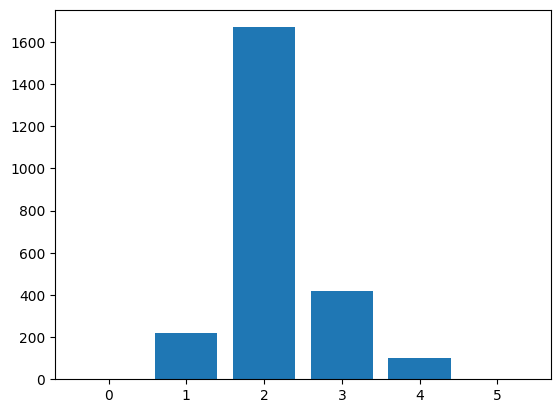

In [9]:
h = nx.degree_histogram(G)
plt.bar(np.arange(len(h)), h)

# reduce redundnat nodes
remove nodes with 2 edges; keep everything else, i.e, junctions and dead end

In [10]:
G.nodes(data=True)

NodeDataView({81376: {'x': -3592.003, 'y': -2032.856, 'z': -4.209}, 38468: {'x': -3574.35, 'y': -2092.284, 'z': -4.003}, 98610: {'x': -3591.979, 'y': -1971.034, 'z': -4.199}, 84126: {'x': -3565.749, 'y': -1903.173, 'z': -3.637}, 109303: {'x': -5581.898, 'y': 3922.396, 'z': -10.137}, 100798: {'x': -5608.285, 'y': 3901.454, 'z': -6.044}, 117681: {'x': -5531.946, 'y': 3980.352, 'z': -14.34}, 119573: {'x': -5498.678, 'y': 4049.252, 'z': -11.316}, 119574: {'x': -5491.021, 'y': 4076.943, 'z': -8.358}, 76466: {'x': -5196.171, 'y': 4617.086, 'z': 2.973}, 109566: {'x': -5040.188, 'y': 4707.479, 'z': -14.936}, 83602: {'x': -5115.664, 'y': 4665.968, 'z': -8.567}, 110422: {'x': -4963.092, 'y': 4745.86, 'z': -16.016}, 101233: {'x': -4884.475, 'y': 4781.062, 'z': -10.761}, 102951: {'x': -1682.562, 'y': 5650.495, 'z': -4.311}, 119138: {'x': -1646.529, 'y': 5609.722, 'z': -5.983}, 73180: {'x': -1605.808, 'y': 5573.606, 'z': -7.069}, 84346: {'x': -1469.581, 'y': 5500.473, 'z': -6.948}, 65650: {'x': -13

In [11]:
G.degree[81376], list(G.neighbors(81376))

(2, [38468, 98610])

In [12]:
# find nodes whose edge not equal to 2
not_2 = pd.DataFrame({'node': list(dict(G.degree).keys()),
                      'degree': list(dict(G.degree).values() )})

not_2 = not_2.loc[not_2['degree'] != 2].sort_values('degree', ascending=False)

In [13]:
# remove nodes with 2 edges and connect junctions to other junctions/edges
# meanwhile store road network distance distances (1 unit in coordinate = 4 meters)
def is_weak_disconnect(node, n=6):
    '''
    ignore node if its part of a disconnected graph with less than
    n nodes
    '''
    for g in nx.connected_components(G):
        if node in g:
            if len(g) < n:
                return True
            else: 
                return False


def get_euclidean_distance(x, y):
    p1 = np.array([G.nodes[x]['x'], G.nodes[x]['y']])
    p2 = np.array([G.nodes[y]['x'], G.nodes[y]['y']])
    distance = np.linalg.norm(p1 - p2).item()*4
    return round(distance, 3)

def next_junction(from_node, to_node):
    if G.degree[to_node] != 2: # if junction/dead-end
        distance = G[from_node][to_node].get('distance', False)
        if not(distance): # find norm 2 euclidean distance; if not present
            distance = get_euclidean_distance(from_node, to_node)
        return to_node, distance
       
    else: # traverse until junction/dead-end found
        # next node thats not fom node
        next_node = list(G.neighbors(to_node))
        next_node.remove(from_node)
        next_node = next_node[0] 
        junction_node, cum_distance = next_junction(to_node, next_node) # recursive
        distance = get_euclidean_distance(to_node, next_node)
        distance += cum_distance
        return junction_node, distance


for node in tqdm(not_2['node'].to_list()):
    if is_weak_disconnect(node):
        continue
    for neighbour in list(G.neighbors(node)):
        
        # get junction/dead-end and distance to it
        junction_node, distance = next_junction(node, neighbour)
        G.add_edge(node, junction_node) # create new edge
        G[node][junction_node]['distance'] = distance # set distance
        

  0%|          | 0/744 [00:00<?, ?it/s]

100%|██████████| 744/744 [00:00<00:00, 1577.97it/s]


In [14]:
# delete all nodes with 2 edges, now that we've connected all junctions and dead-ends together
is_2 = pd.DataFrame({'node': list(dict(G.degree).keys()),
                      'degree': list(dict(G.degree).values() )})

is_2 = is_2.loc[is_2['degree'] == 2]

for node in is_2['node'].to_list():
    G.remove_node(node)

# remove remove isolated nodes
lst = list(nx.isolates(G))
for isolate in lst:
    G.remove_node(isolate)

del lst

In [15]:
# remove nodes part of disconnected subgraphs with less than 10 nodes
lst = list(nx.connected_components(G))
for g in lst:
        if len(g) < 10:
            for node in g:
                    G.remove_node(node)
del lst

<BarContainer object of 6 artists>

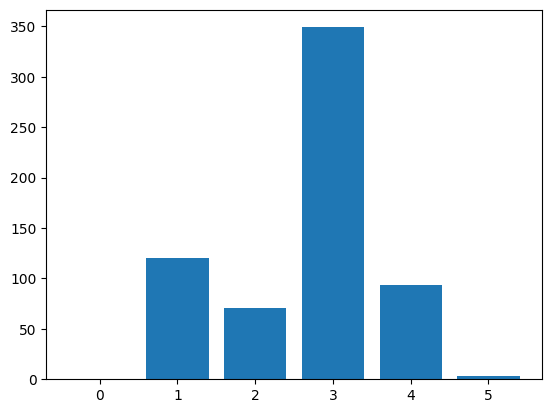

In [16]:
h = nx.degree_histogram(G)
plt.bar(np.arange(len(h)), h)

In [17]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(avg_degree) 

2.6666666666666665


In [18]:
for g in nx.connected_components(G):
    print(len(g))
print(f'total: {G.number_of_nodes()}')

129
507
total: 636


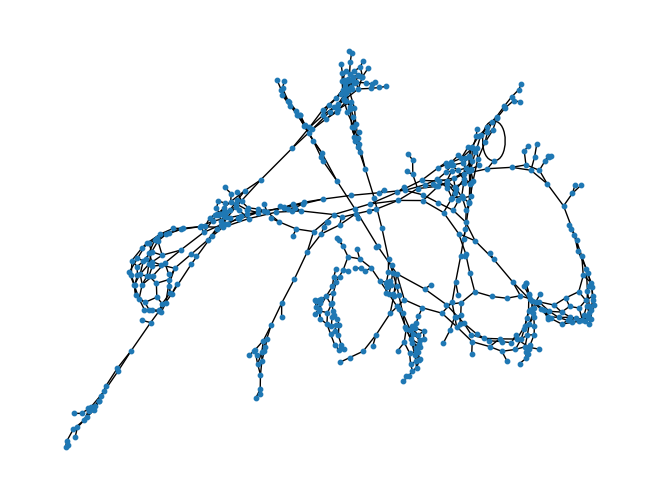

In [19]:

nx.draw(G, node_size=10)

# export as data frame

In [20]:
export_df = pd.DataFrame(list(G.edges()), columns=['from_node', 'to_node'])

In [21]:
export_df['distance'] = export_df.apply(lambda x: round(G[x[0]][x[1]]['distance'], 3), axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_14740\2088898392.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  export_df['distance'] = export_df.apply(lambda x: round(G[x[0]][x[1]]['distance'], 3), axis=1)


In [22]:
# to and from coordinates
for s in ['from', 'to']:
    export_df = pd.merge(left=export_df, right=unique_node,
                        left_on=f'{s}_node', right_on='node0')
    export_df.rename(columns={'x_0':f'x_{s}', 'y_0':f'y_{s}' , 'z_0':f'z_{s}' }, inplace=True)
    export_df.drop(columns=['node0', 'node_attribute'], inplace=True)

In [23]:
export_df.iloc[0]

from_node     76466.000
to_node      101982.000
distance       1094.068
x_from        -5196.171
y_from         4617.086
z_from            2.973
x_to          -5374.425
y_to           4400.001
z_to              0.884
Name: 0, dtype: float64

100%|██████████| 848/848 [00:00<00:00, 1380.94it/s]


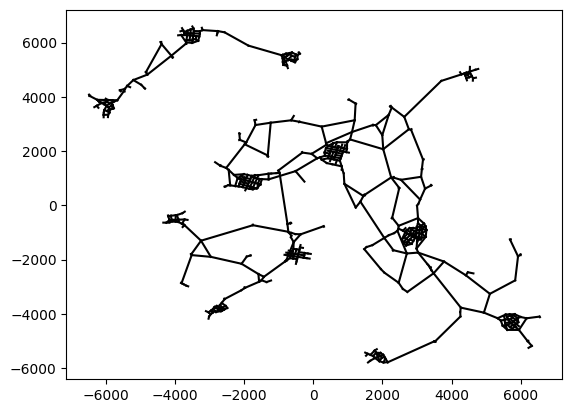

In [27]:
for i in tqdm(range(len(export_df))):
    x = export_df[['x_from', 'x_to']].iloc[i].to_list()
    y = export_df[['y_from', 'y_to']].iloc[i].to_list()
    plt.plot(x,y,'k')

In [28]:
export_df.to_csv(r'C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\processed\road_next_word.csv', index=False)